In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm

### Connexion à la DB / Import des Data


In [2]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/Github/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

### Import de la table DuckDB

In [3]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "user_segments_kmeans"
TABLE_SEGMENTS = "user_segments_kmeans"
SAMPLE_USER_PERCENT = 0.2
BATCH_SIZE = 1000 

In [4]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌──────────────────────┐
│         name         │
│       varchar        │
├──────────────────────┤
│ all_events           │
│ loaded_files         │
│ user_events          │
│ user_segments_kmeans │
└──────────────────────┘



In [5]:
# Examine the all_events table
print(f"First 10 rows of {TABLE_EVENTS} table:")
user_segments = con.sql(f"""
    SELECT * FROM {TABLE_EVENTS} ORDER BY RANDOM() LIMIT 2000
""")
user_segments.show()
user_segments_df = user_segments.df()


First 10 rows of user_segments_kmeans table:
┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬───────────────────┬────────────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┬─────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │    total_spent    │     avg_basket     │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │ segment │
│  varchar  │    int64     │   double    │     double      │         double          │      double       │       double       │      timestamp      │        double        │        double        │         int64         │  int32  │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼───────────────────┼────────────────────┼─────────────────────┼──────────────────────┼──────────────────────┼───────────────────────┼─────────┤
│ 527054502 │           72 │       

In [6]:
user_segments_df.describe()

,total_events,total_views,total_purchases,avg_time_between_events,total_spent,avg_basket,last_event_time,conversion_rate,purchase_ratio,days_since_last_event,segment
count,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000,2000,2000.000000,2000.000000,2000.000000,2000.000000
mean,45.510500,64.044500,1.257500,2.062869e+05,376.341730,85.811174,2020-02-29 04:17:47.047499,0.030151,0.024499,31.720000,1.580500
min,10.000000,2.000000,0.000000,2.421053e+00,0.000000,0.000000,2019-10-01 16:39:05,0.000000,0.000000,-30.000000,0.000000
25%,17.000000,15.000000,0.000000,3.172551e+04,0.000000,0.000000,2020-01-18 12:13:15.750000,0.000000,0.000000,-19.000000,1.000000
50%,29.000000,27.000000,0.000000,1.148110e+05,0.000000,0.000000,2020-03-15 16:41:00,0.000000,0.000000,16.000000,2.000000
75%,68.000000,63.000000,1.000000,2.678602e+05,144.325000,94.083125,2020-04-20 10:51:01,0.019231,0.018868,73.000000,2.000000
max,114.000000,2739.000000,132.000000,1.803292e+06,48213.860000,2072.100000,2020-04-30 23:16:24,1.250000,0.555556,182.000000,3.000000
std,36.213486,126.261215,4.981727,2.627389e+05,1920.544751,195.731016,NaN,0.085692,0.058633,57.598093,0.663883


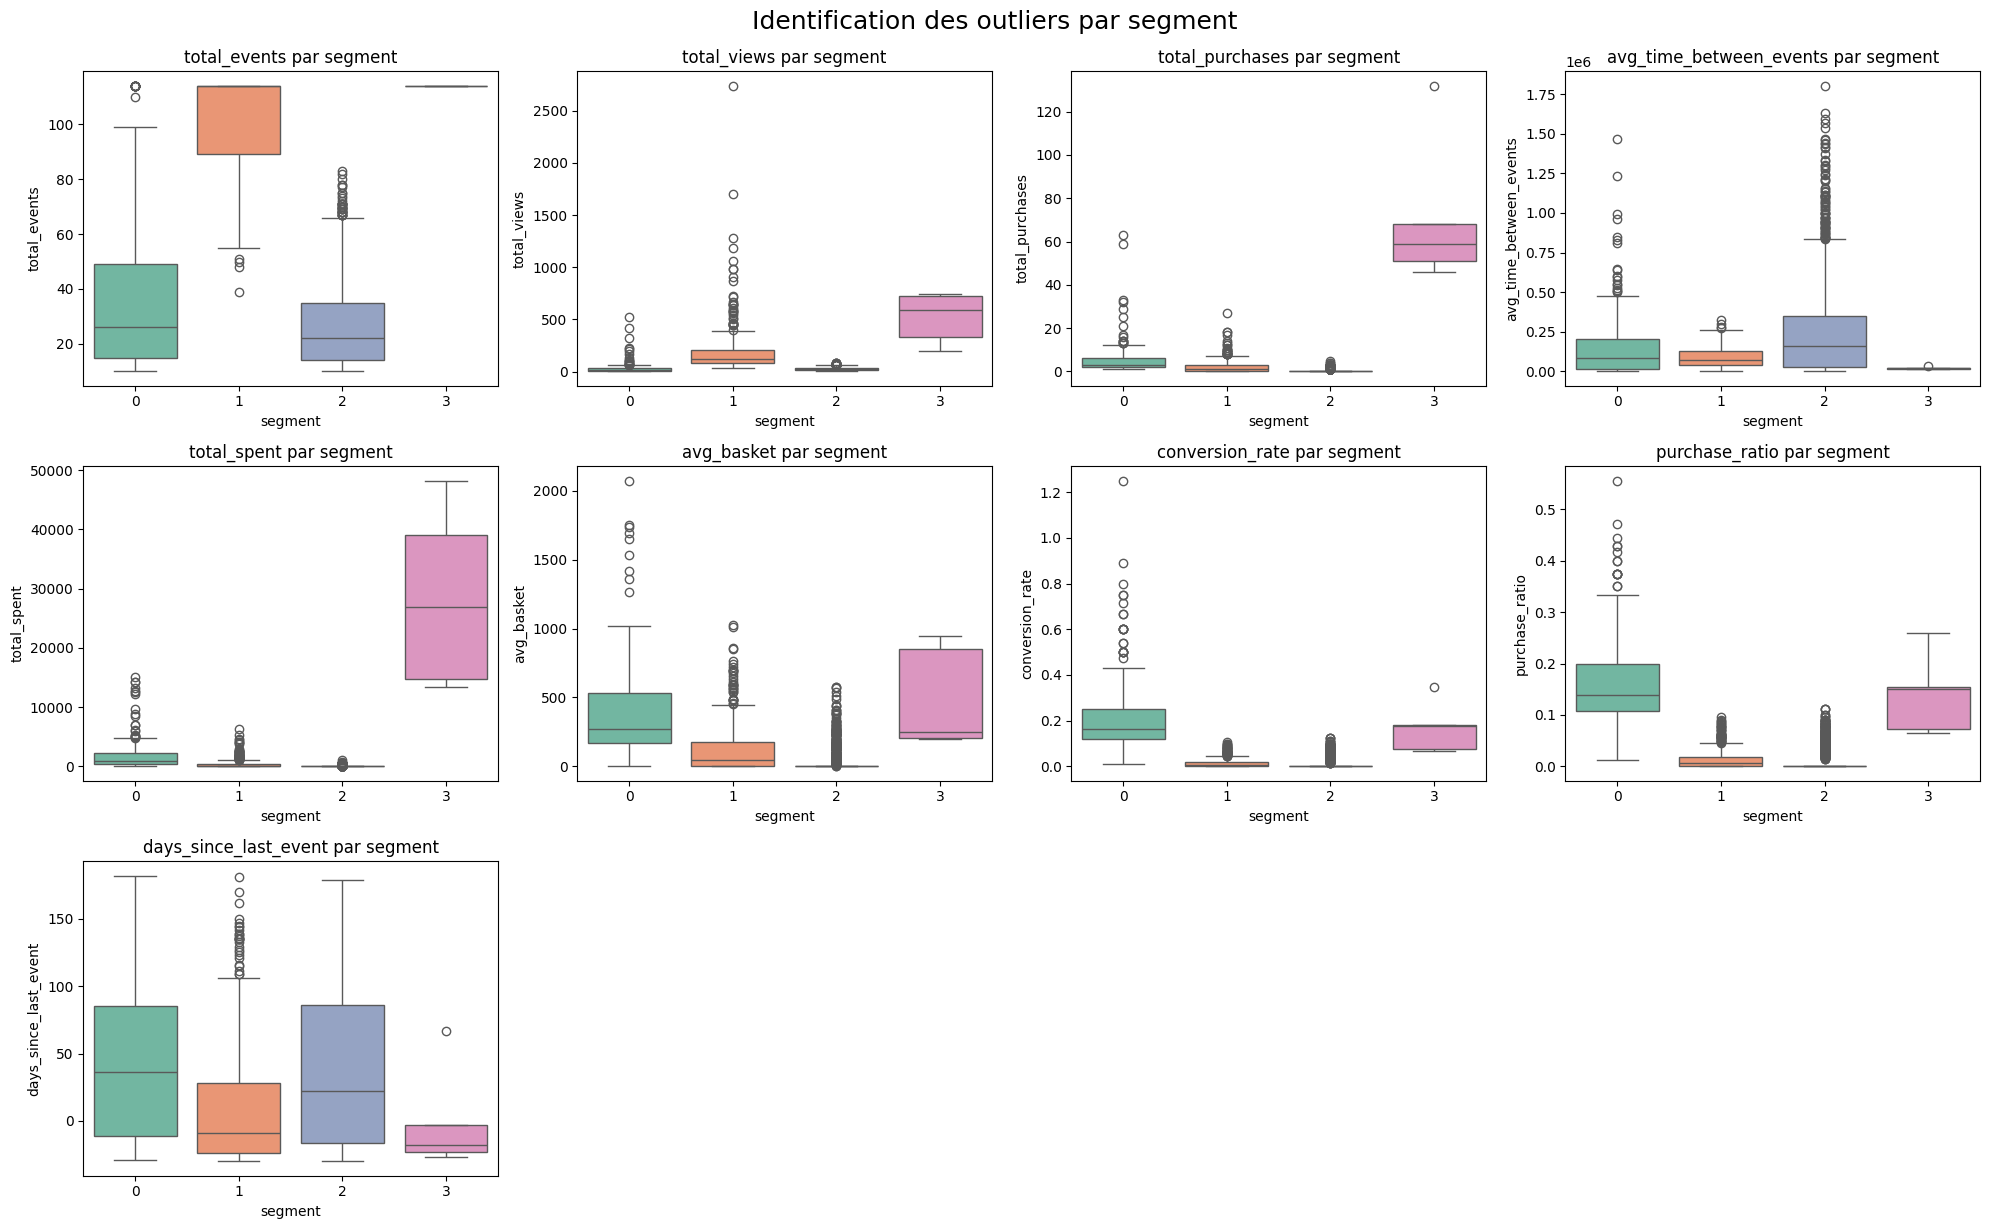


Total unique outliers found: 30
Outliers by column:
  total_purchases: 14 outliers
  total_spent: 8 outliers
  avg_basket: 6 outliers
  total_views: 6 outliers


In [7]:
desc_by_class = user_segments_df.copy()

# Group by segment column and get descriptive statistics
grouped_summary = desc_by_class.groupby("segment").describe().T

outlier_indices = {}

# Iterate through each segment
for cls in desc_by_class["segment"].unique():
    df_class = desc_by_class[desc_by_class["segment"] == cls]
    for col in df_class.columns:
        # Skip non-numeric and grouping columns
        if col in ["segment", "last_event_time"]:
            continue
        # Skip if column is not numeric
        if not pd.api.types.is_numeric_dtype(df_class[col]):
            continue
            
        q1 = df_class[col].quantile(0.05)
        q3 = df_class[col].quantile(0.95)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr
        outliers = df_class[(df_class[col] < lower_bound) | (df_class[col] > upper_bound)]
        if not outliers.empty:
            if col not in outlier_indices:
                outlier_indices[col] = []
            outlier_indices[col].extend(outliers.index.tolist())

unique_outlier_indices = sorted(set(sum(outlier_indices.values(), [])))
outlier_rows = desc_by_class.loc[unique_outlier_indices]

# Get numeric columns excluding segment and timestamp
numeric_cols = desc_by_class.select_dtypes(include=[np.number]).drop(columns=["segment"]).columns
n_cols = len(numeric_cols)
n_rows = (n_cols + 3) // 4  # Calculate rows needed for 4 columns

plt.figure(figsize=(20, n_rows * 4))
for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, 4, i + 1)
    sns.boxplot(data=desc_by_class, y=col, x="segment", hue="segment", palette="Set2", legend=False)
    plt.title(f"{col} par segment")
    plt.tight_layout()

plt.suptitle("Identification des outliers par segment", fontsize=18, y=1.02)
plt.show()

print(f"\nTotal unique outliers found: {len(unique_outlier_indices)}")
print(f"Outliers by column:")
for col, indices in outlier_indices.items():
    print(f"  {col}: {len(set(indices))} outliers")

### Normalisation et Standardisation des données

In [8]:
from sklearn.preprocessing import StandardScaler

numeric_features = user_segments_df.drop(
    columns=["last_event_time"]
)

num_scaler = StandardScaler()
X_num_scaled = num_scaler.fit_transform(numeric_features)


In [9]:
# After scaling, create a DataFrame with scaled values and add segment column
X_num_scaled_df = pd.DataFrame(X_num_scaled, columns=numeric_features.columns)
X_num_scaled_df["segment"] = user_segments_df["segment"].values

clusters = X_num_scaled_df["segment"].value_counts().keys()
clusters

Index([2, 1, 0, 3], dtype='int32', name='segment')

Text(0.5, 1.0, 'Matrice de corrélation des variables numériques')

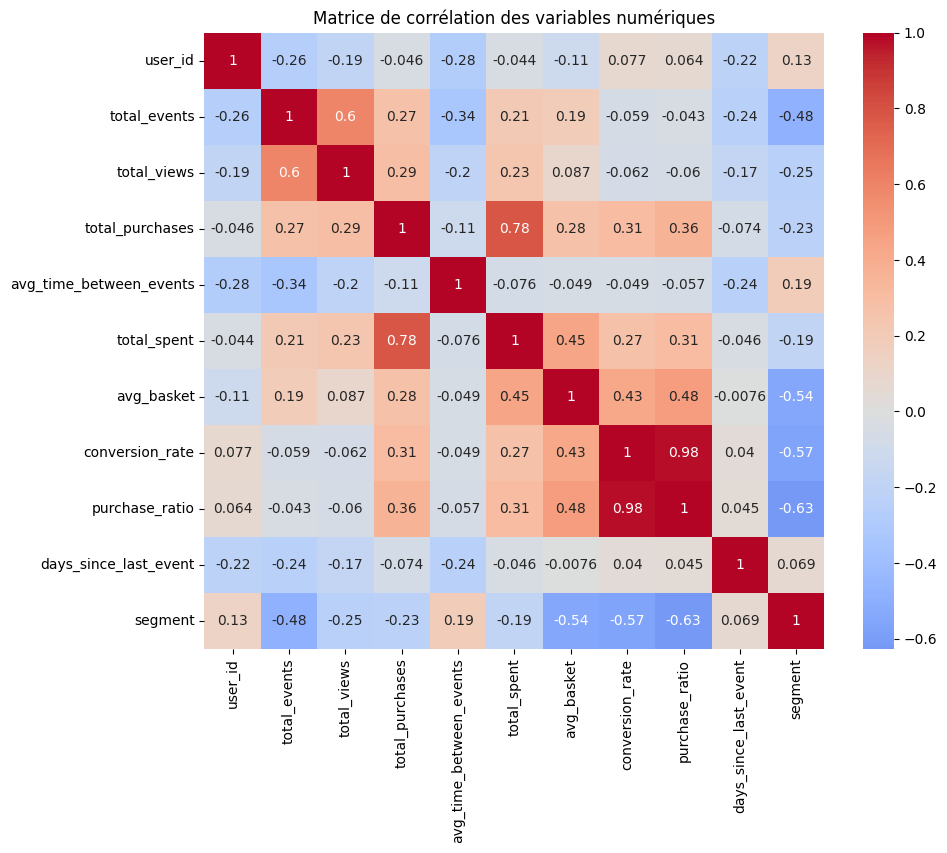

In [10]:
# Matrice de Corréaltion
# Correlation between numerical columns
numeric_columns = X_num_scaled_df.select_dtypes(include=[np.number]).columns
correlation = X_num_scaled_df[numeric_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0)
plt.title('Matrice de corrélation des variables numériques')



In [11]:
for c in clusters:
    segment_data = X_num_scaled_df[X_num_scaled_df["segment"] == c].copy()
    # Convert int32 columns to int64 to avoid dtype warnings
    int32_cols = segment_data.select_dtypes(include=['int32']).columns
    segment_data[int32_cols] = segment_data[int32_cols].astype('int64')
    
    profile_report = ProfileReport(
        segment_data, 
        title=f"Profiling Report - Segment {c}",
        progress_bar=False
    )
    profile_report.to_file(f"profile_report_segment_{c}.html")
    print(f"✓ Generated report for segment {c}")

100%|██████████| 11/11 [00:00<00:00, 4061.03it/s]


✓ Generated report for segment 2


100%|██████████| 11/11 [00:00<00:00, 3650.11it/s]


✓ Generated report for segment 1


100%|██████████| 11/11 [00:00<00:00, 20952.47it/s]


✓ Generated report for segment 0


100%|██████████| 11/11 [00:00<00:00, 304.00it/s]


✓ Generated report for segment 3


In [12]:
con.close()